# 11. Konvolucione neuronske mreže (CNN)

## Računarski vid

**Računarski vid** je oblast veštačke inteligencije koja omogućava računarima da
interpretiraju, razumeju i izvuku informacije iz **vizuelnih podataka** (slike, video,
kamere). Cilj je da mašine „vide" i razumeju svet na način sličan ljudskoj percepciji.

Primene: klasifikacija slika, detekcija objekata, segmentacija, prepoznavanje lica i
emocija, autonomna vozila, medicinska dijagnostika, maloprodaja (Amazon Go),
poljoprivreda, AI-generisane slike.

## Zašto klasični ML ne radi dobro na slikama

1. Slike imaju **veoma veliki broj ulaznih karakteristika** (piksela)
2. **Gubi se prostorna struktura slike kada se pikseli vektorizuju**
3. Klasični algoritmi ne koriste **lokalne obrasce** (ivice, teksture)
4. Ne skaliraju dobro na visoke dimenzije
5. Ručno izdvajanje karakteristika je složeno, neefikasno i zavisi od domena

### Izazov dimenzionalnosti — konkretno

| slika | broj ulaznih karakteristika |
|---|---|
| $64 \times 64 \times 3$ | 12.288 |
| $1000 \times 1000 \times 3$ | **~3 miliona** |

Potpuno povezan sloj sa 1000 neurona nad slikom od 3 miliona piksela ima
**~3 milijarde parametara** → ogromna memorija, sporo treniranje, neefikasan model.

### Rešenje — CNN

Konvolucija **deli težine** između različitih delova slike, čime se broj parametara
drastično smanjuje. CNN koristi **prostornu strukturu** slike i fokusira se na
**lokalne obrasce**.

In [1]:
import warnings, os
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

plt.rcParams["figure.figsize"] = (9, 4.5); plt.rcParams["figure.dpi"] = 110
RS = 42
np.random.seed(RS); tf.random.set_seed(RS)

for h, w, c in [(28, 28, 1), (64, 64, 3), (1000, 1000, 3)]:
    ul = h * w * c
    par = ul * 1000 + 1000
    print(f"slika {h}x{w}x{c}: {ul:>9,} ulaza  ->  FC sloj sa 1000 neurona = {par:>15,} parametara")

slika 28x28x1:       784 ulaza  ->  FC sloj sa 1000 neurona =         785,000 parametara
slika 64x64x3:    12,288 ulaza  ->  FC sloj sa 1000 neurona =      12,289,000 parametara
slika 1000x1000x3: 3,000,000 ulaza  ->  FC sloj sa 1000 neurona =   3,000,001,000 parametara


## Konvoluciona operacija

Osnovni element CNN-a. Koristi se za otkrivanje **lokalnih obrazaca**, kao što su ivice.

**Hijerarhija osobina:**

| nivo | šta detektuje |
|---|---|
| **niski** | ivice, kontrasti |
| **srednji** | delovi objekata (oči, uši, nos) |
| **visoki** | kompletna struktura objekta (lice) |

### Veličina izlaza

$$\text{Output} = \left\lfloor \frac{n + 2p - f}{s} \right\rfloor + 1$$

| oznaka | značenje |
|---|---|
| $n$ | dimenzija ulaza |
| $f$ | veličina filtera (kernela) |
| $p$ | veličina padding-a |
| $s$ | stride |

**Primer:** $n=6$, $f=3$, $p=0$, $s=1$ → $\frac{6+0-3}{1}+1 = 4$

> **Važno:** vrednosti u kernelu **nisu fiksne** — one se **uče tokom treniranja**, kao i
> sve druge težine mreže.

Ulaz (6, 6) * kernel (3, 3), stride=1, padding=0
Izlaz: (6 + 0 - 3)/1 + 1 = (4, 4)



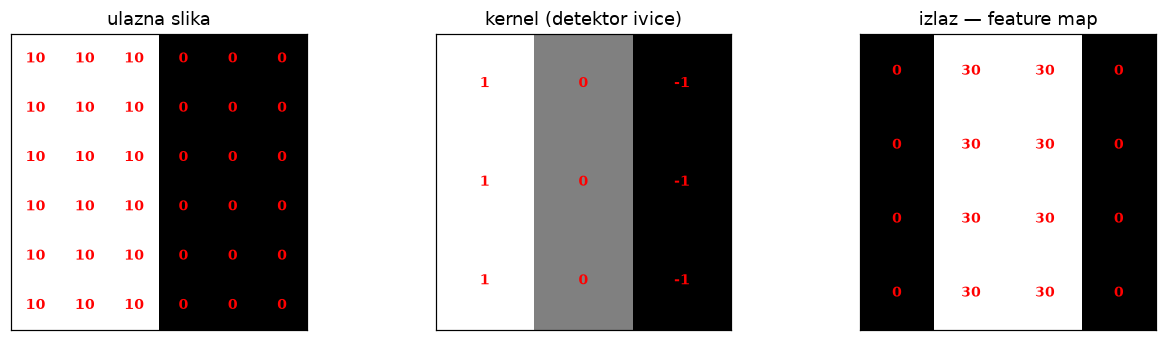

-> Kernel je detektovao vertikalnu ivicu: izlaz je nula svuda osim na prelazu.


In [2]:
def konvolucija(slika, kernel, stride=1, padding=0):
    'Rucna 2D konvolucija — da se vidi sta operacija radi.'
    if padding > 0:
        slika = np.pad(slika, padding, mode="constant")
    n, f = slika.shape[0], kernel.shape[0]
    izlaz_dim = (n - f) // stride + 1
    izlaz = np.zeros((izlaz_dim, izlaz_dim))
    for i in range(izlaz_dim):
        for j in range(izlaz_dim):
            isecak = slika[i*stride:i*stride+f, j*stride:j*stride+f]
            izlaz[i, j] = np.sum(isecak * kernel)      # skalarni proizvod
    return izlaz

ulaz = np.array([[10,10,10,0,0,0]]*6, dtype=float)      # vertikalna ivica u sredini
kernel_v = np.array([[1,0,-1],[1,0,-1],[1,0,-1]], float)

izlaz = konvolucija(ulaz, kernel_v)
print(f"Ulaz {ulaz.shape} * kernel {kernel_v.shape}, stride=1, padding=0")
print(f"Izlaz: (6 + 0 - 3)/1 + 1 = {izlaz.shape}\n")

fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
for a, (d, t) in zip(ax, [(ulaz, "ulazna slika"), (kernel_v, "kernel (detektor ivice)"),
                          (izlaz, "izlaz — feature map")]):
    im = a.imshow(d, cmap="gray"); a.set_title(t); a.set_xticks([]); a.set_yticks([])
    for (i, j), v in np.ndenumerate(d):
        a.text(j, i, f"{v:.0f}", ha="center", va="center",
               color="red", fontsize=9, fontweight="bold")
plt.tight_layout(); plt.show()
print("-> Kernel je detektovao vertikalnu ivicu: izlaz je nula svuda osim na prelazu.")

## Padding

**Problem osnovne konvolucije (bez padding-a):**

1. dimenzije izlaza se **smanjuju** sa svakim slojem ($6\times6 \to 4\times4$)
2. pikseli na **ivicama** slike se nedovoljno koriste
3. gubi se informacija sa ivica

**Rešenje — padding:** dodavanje ivica (najčešće nula) oko ulazne slike. Omogućava
očuvanje dimenzija, ravnopravno korišćenje ivica i **dublje** CNN arhitekture.

| tip | padding | rezultat |
|---|---|---|
| **Valid** | $p = 0$ | dimenzije se smanjuju |
| **Same** | $p$ takav da izlaz = ulaz | dimenzije očuvane |

Najčešće veličine filtera: $3\times3$, $5\times5$, $7\times7$.
U praksi se najčešće koristi **$3\times3$ sa same padding-om**.

In [3]:
print(f"{'ulaz':>6} {'filter':>7} {'padding':>8} {'stride':>7} {'izlaz':>7}  tip")
print("-" * 52)
for n, f, p, s in [(6,3,0,1), (6,3,1,1), (7,3,0,2), (28,3,1,1), (28,3,0,1), (28,5,2,1)]:
    izl = (n + 2*p - f)//s + 1
    tip = "same" if izl == n else "valid"
    print(f"{n:>6} {f:>7} {p:>8} {s:>7} {izl:>7}  {tip}")

valid = konvolucija(ulaz, kernel_v, padding=0)
same = konvolucija(ulaz, kernel_v, padding=1)
print(f"\nValid konvolucija: {ulaz.shape} -> {valid.shape}")
print(f"Same konvolucija : {ulaz.shape} -> {same.shape}   (dimenzija ocuvana)")

  ulaz  filter  padding  stride   izlaz  tip
----------------------------------------------------
     6       3        0       1       4  valid
     6       3        1       1       6  same
     7       3        0       2       3  valid
    28       3        1       1      28  same
    28       3        0       1      26  valid
    28       5        2       1      28  same

Valid konvolucija: (6, 6) -> (4, 4)
Same konvolucija : (6, 6) -> (6, 6)   (dimenzija ocuvana)


## Strided convolutions

**Stride** ($s$) određuje za koliko piksela se filter pomera po širini i visini.

**Zašto se koristi:**
- smanjuje prostorne dimenzije izlazne mape osobina
- kontroliše veličinu izlaza **bez** pooling sloja
- smanjuje računarsku složenost

**Veći stride ⇒ manji izlaz.**

## 3D konvolucija

Do sada smo posmatrali 2D slike u nijansama sive. Kod **RGB** slika treća dimenzija su
kanali boja.

**Ključni uslov:** broj kanala **ulaza** mora biti jednak broju kanala **filtera**.

Primer: ulaz $6\times6\times3$, filter $3\times3\times3$ → izlaz $4\times4\times1$.

Filter se primenjuje na sve kanale istovremeno, a rezultati se **sabiraju**. Iako je filter
3D, izlaz jedne konvolucije je i dalje **2D mapa osobina**.

> **Više filtera → više izlaznih kanala.** Svaki filter proizvodi jednu feature mapu,
> a mape se slažu po dubini.

Svaka feature mapa ima **sopstveni bias** (skalar) koji se dodaje svim elementima, pa se
na rezultat primenjuje aktivaciona funkcija (ReLU).

In [4]:
ulaz3d = np.random.RandomState(RS).rand(6, 6, 3)
filter3d = np.random.RandomState(1).randn(3, 3, 3)

n, f = 6, 3
izlaz_dim = n - f + 1
rez = np.zeros((izlaz_dim, izlaz_dim))
for i in range(izlaz_dim):
    for j in range(izlaz_dim):
        rez[i, j] = np.sum(ulaz3d[i:i+f, j:j+f, :] * filter3d)   # sabira SVE kanale

print(f"Ulaz     : {ulaz3d.shape}  (6x6 RGB)")
print(f"Filter   : {filter3d.shape}  (3x3, mora imati ISTI broj kanala)")
print(f"Izlaz    : {rez.shape}  <- 2D, jedna feature mapa")
print(f"\nSa 8 filtera izlaz bi bio: ({izlaz_dim}, {izlaz_dim}, 8)")

Ulaz     : (6, 6, 3)  (6x6 RGB)
Filter   : (3, 3, 3)  (3x3, mora imati ISTI broj kanala)
Izlaz    : (4, 4)  <- 2D, jedna feature mapa

Sa 8 filtera izlaz bi bio: (4, 4, 8)


## Pooling sloj (subsampling)

Pooling sloj **smanjuje prostorne dimenzije** feature mapa (širinu i visinu):

- zadržava najvažnije informacije
- smanjuje broj parametara i računsku složenost
- povećava otpornost na **male translacije** u slici

| vrsta | operacija | učestalost |
|---|---|---|
| **Max Pooling** | bira **najveću** vrednost | najčešći u CNN-ovima |
| **Average Pooling** | računa **prosek** | ređe u praksi |

> **Pooling ne uči parametre** — on samo sažima informacije.

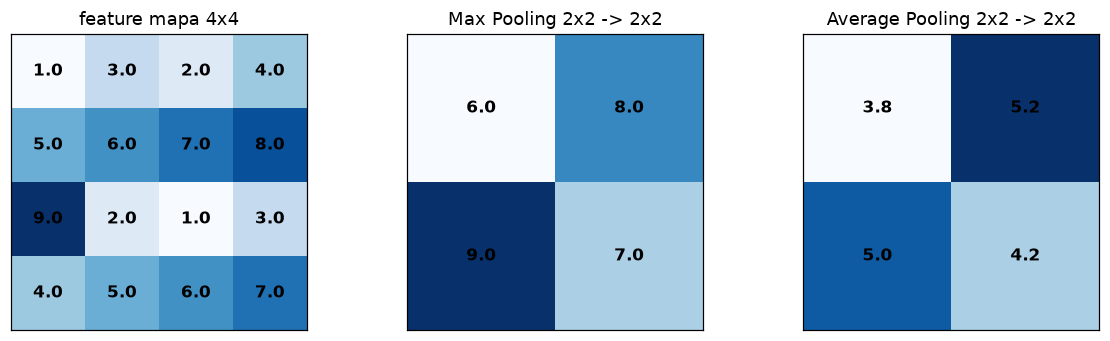

Pooling NEMA parametre koji se uce — samo sazima.


In [5]:
mapa = np.array([[1,3,2,4],[5,6,7,8],[9,2,1,3],[4,5,6,7]], float)

def pooling(x, k=2, s=2, tip="max"):
    d = (x.shape[0]-k)//s + 1
    o = np.zeros((d, d))
    for i in range(d):
        for j in range(d):
            w = x[i*s:i*s+k, j*s:j*s+k]
            o[i, j] = w.max() if tip == "max" else w.mean()
    return o

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
for a, (d, t) in zip(ax, [(mapa, "feature mapa 4x4"),
                          (pooling(mapa, tip="max"), "Max Pooling 2x2 -> 2x2"),
                          (pooling(mapa, tip="avg"), "Average Pooling 2x2 -> 2x2")]):
    a.imshow(d, cmap="Blues"); a.set_title(t); a.set_xticks([]); a.set_yticks([])
    for (i, j), v in np.ndenumerate(d):
        a.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()
print("Pooling NEMA parametre koji se uce — samo sazima.")

## Kompletna CNN arhitektura

Tipičan raspored: `Conv → ReLU → Pool` (ponovljeno) → `Flatten` → `Dense` → izlaz.

In [6]:
digits = load_digits()
X = digits.images[..., None] / 16.0          # 8x8x1, skalirano na [0,1]
y = digits.target
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=RS, stratify=y)

cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(8, 8, 1)),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation="softmax"),      # 10 cifara -> softmax
])
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,314 (368.41 KB)

 Trainable params: 94,314 (368.41 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
h = cnn.fit(Xtr, ytr, validation_split=0.2, epochs=30, batch_size=64, verbose=0)
print(f"Tacnost na testu: {cnn.evaluate(Xte, yte, verbose=0)[1]:.4f}")

# poredjenje sa istom mrezom koja NE koristi prostornu strukturu
mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(8, 8, 1)),
    tf.keras.layers.Flatten(),                            # spljosti — gubi prostor!
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])
mlp.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
mlp.fit(Xtr, ytr, validation_split=0.2, epochs=30, batch_size=64, verbose=0)

print(f"\n{'model':<28} {'parametara':>12} {'tacnost':>9}")
print("-" * 52)
print(f"{'CNN (cuva prostor)':<28} {cnn.count_params():>12,} {cnn.evaluate(Xte, yte, verbose=0)[1]:>9.4f}")
print(f"{'MLP (Flatten na pocetku)':<28} {mlp.count_params():>12,} {mlp.evaluate(Xte, yte, verbose=0)[1]:>9.4f}")

Tacnost na testu: 0.9756



model                          parametara   tacnost
----------------------------------------------------
CNN (cuva prostor)                 94,314    0.9756
MLP (Flatten na pocetku)            8,970    0.9778


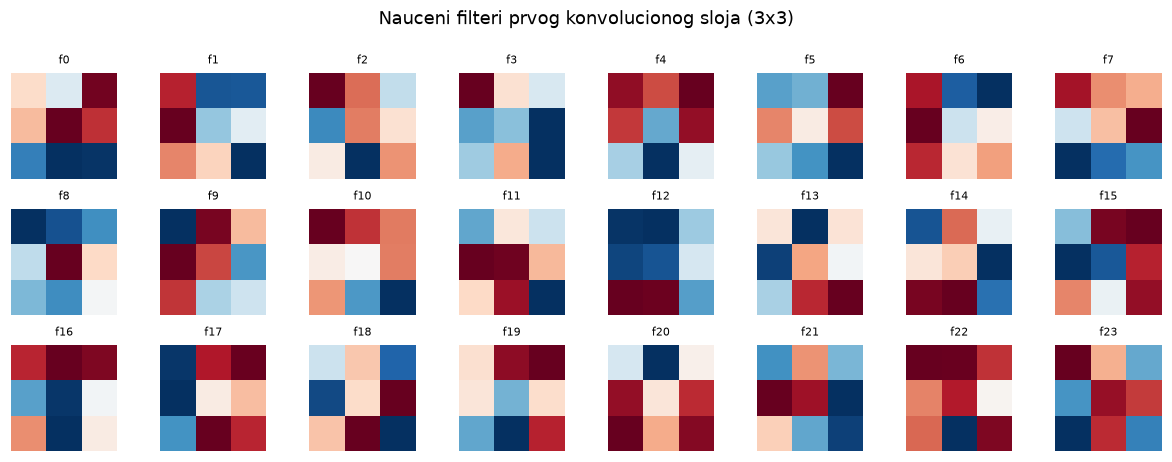

Vrednosti u filterima NISU zadate — mreza ih je naucila iz podataka.


In [8]:
# sta su filteri prvog sloja naucili
w = cnn.layers[0].get_weights()[0]           # (3, 3, 1, 32)
fig, ax = plt.subplots(3, 8, figsize=(11, 4.2))
for i, a in enumerate(ax.ravel()):
    if i < w.shape[-1]:
        a.imshow(w[:, :, 0, i], cmap="RdBu_r")
        a.set_title(f"f{i}", fontsize=7)
    a.axis("off")
plt.suptitle("Nauceni filteri prvog konvolucionog sloja (3x3)", y=0.99)
plt.tight_layout(); plt.show()
print("Vrednosti u filterima NISU zadate — mreza ih je naucila iz podataka.")

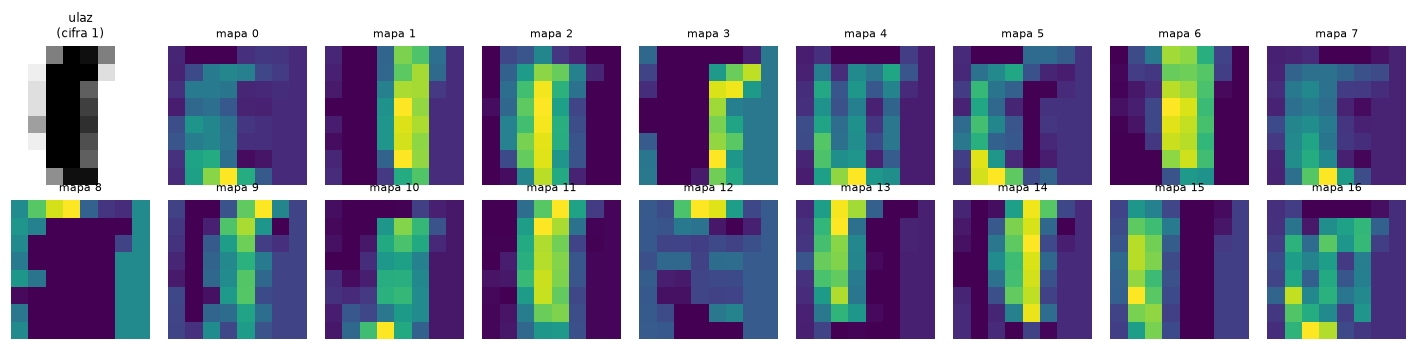

In [9]:
# feature mape — sta filter "vidi" na konkretnoj slici
izdvoji = tf.keras.Model(cnn.inputs, cnn.layers[0].output)
slika = Xte[0:1]
mape = izdvoji.predict(slika, verbose=0)[0]

fig, ax = plt.subplots(2, 9, figsize=(13, 3.2))
ax[0, 0].imshow(slika[0, :, :, 0], cmap="gray_r")
ax[0, 0].set_title(f"ulaz\n(cifra {yte[0]})", fontsize=8)
for i, a in enumerate(ax.ravel()[1:]):
    if i < mape.shape[-1]:
        a.imshow(mape[:, :, i], cmap="viridis")
        a.set_title(f"mapa {i}", fontsize=7)
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

## Poznate CNN arhitekture

| arhitektura | godina | doprinos |
|---|---|---|
| **LeNet-5** | 1998 | jedna od prvih; prepoznavanje rukom pisanih cifara; `Conv → Pool → FC` |
| **AlexNet** | 2012 | pobednik ImageNet-a; popularizovala duboko učenje; uvela **ReLU**, **dropout**, rad na **GPU** |
| **VGGNet** | 2014 | duboka mreža sa malim **3×3** filterima; jednostavna, ali mnogo parametara |
| **GoogLeNet / Inception** | 2014 | Inception blokovi; smanjuje broj parametara |
| **ResNet** | 2015 | **residual (skip) connections**; omogućava treniranje mreža sa 50+, 100+ slojeva |

## Sažetak

- **konvolucija** — deli težine, hvata lokalne obrasce, drastično smanjuje broj parametara
- **padding** — čuva dimenzije i ivične piksele
- **stride** — kontroliše veličinu izlaza
- **pooling** — sažima, ne uči parametre, daje otpornost na male pomeraje
- filteri se **uče**, ne zadaju